1. Preprocessing

In [53]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.cluster  import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, adjusted_rand_score, normalized_mutual_info_score, confusion_matrix
from sklearn.decomposition import PCA, KernelPCA
from sklearn.model_selection import train_test_split
from scipy.optimize import linear_sum_assignment
from scipy.spatial.distance import cdist

1.1 Load Data

In [54]:
df = pd.read_csv("mice-protein.csv")
print("Shape:", df.shape)
df.head()

df.columns

y_true = df["class"]
X = df.select_dtypes(include=[np.number])

Shape: (1080, 82)


1.2 Missing Values & Standardization

In [55]:

imputer = SimpleImputer(strategy="mean")
X_imputed = imputer.fit_transform(X)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)

print("Processed shape:", X_scaled.shape)

Processed shape: (1080, 77)


Task 1: Clustering Without Dimensionality Reduction

In [56]:

k = y_true.nunique()
print("Number of true classes (k):", k)

Number of true classes (k): 8


1.3 K-Means (5 Seeds)

In [57]:


seeds = [0, 10, 20, 30, 40]
kmeans_labels = []
sil_scores = []

for seed in seeds:
  km = KMeans(n_clusters=k, random_state=seed, n_init=10)
  labels = km.fit_predict(X_scaled)
  sil = silhouette_score(X_scaled, labels)

  kmeans_labels.append(labels)
  sil_scores.append(sil)

print("Average Silhouette (KMeans)", np.mean(sil_scores))

Average Silhouette (KMeans) 0.13391341241151097


1.4 Gaussian Mixture Model (EM)

In [58]:


gmm_sil = []
gmm_labels_list = []
for seed in seeds:
  gmm = GaussianMixture(n_components=k, covariance_type='full', random_state=seed)
  labels = gmm.fit_predict(X_scaled)
  sil = silhouette_score(X_scaled, labels)

  gmm_labels_list.append(labels)
  gmm_sil.append(sil)

print("Average SIlhouette (GMM):", np.mean(gmm_sil))

Average SIlhouette (GMM): 0.11924317271256343


1.5 Kernel K-Means (Using RBF Kernel Approximation)

In [59]:


from sklearn.cluster import SpectralClustering

gamma_values = [1e-3, 1e-2, 1e-1, 1]

best_sil = -1
best_spec_labels = None

for gamma in gamma_values:
  spec = SpectralClustering(n_clusters=k, affinity='rbf', gamma=gamma, random_state=0)
  labels = spec.fit_predict(X_scaled)
  sil = silhouette_score(X_scaled, labels)

  print(f"Gamma={gamma}, Silhouette={sil}")

  if sil > best_sil:
    best_sil = sil
    best_spec_labels = labels

print("Best Spectral Silhouette", best_sil)

Gamma=0.001, Silhouette=0.12373190852036983
Gamma=0.01, Silhouette=0.11805901692513839
Gamma=0.1, Silhouette=0.09890235983765755
Gamma=1, Silhouette=0.30016857381558865
Best Spectral Silhouette 0.30016857381558865


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_spectral_embedding.py:455: UserWarning: Exited at iteration 621 with accuracies 
[5.92627809e-15 1.59038821e-05 1.33895246e-05 8.94185852e-06
 9.75903781e-06 1.96041333e-05 1.22289905e-05 1.77439030e-05
 1.32403561e-05]
not reaching the requested tolerance 1.609325408935547e-05.
Use iteration 621 instead with accuracy 
1.2312409553058842e-05.

  _, diffusion_map = lobpcg(
/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_spectral_embedding.py:455: UserWarning: Exited postprocessing with accuracies 
[3.80867532e-15 1.59038820e-05 1.33895260e-05 8.94185785e-06
 9.75903709e-06 1.96041327e-05 1.22289913e-05 1.77439033e-05
 1.32403556e-05]
not reaching the requested tolerance 1.609325408935547e-05.
  _, diffusion_map = lobpcg(
/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: ConvergenceWarning: Number of distinct clusters (3) found smaller than n_clusters (8). Possibly due to duplicate points in X.
  return fit_m

1.6 2D Visualization

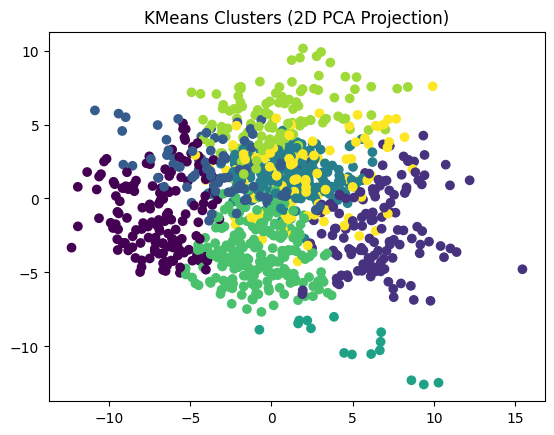

,count
5,224
3,213
0,156
1,138
6,136
7,114
2,84
4,15


In [60]:


pca_2d = PCA(n_components=2)
X_2d = pca_2d.fit_transform(X_scaled)

plt.figure()
plt.scatter(X_2d[:,0], X_2d[:,1], c=kmeans_labels[0])
plt.title("KMeans Clusters (2D PCA Projection)")
plt.show()

pd.Series(kmeans_labels[0]).value_counts()

Task 2: Dimensionality Reduction

2.1 PCA

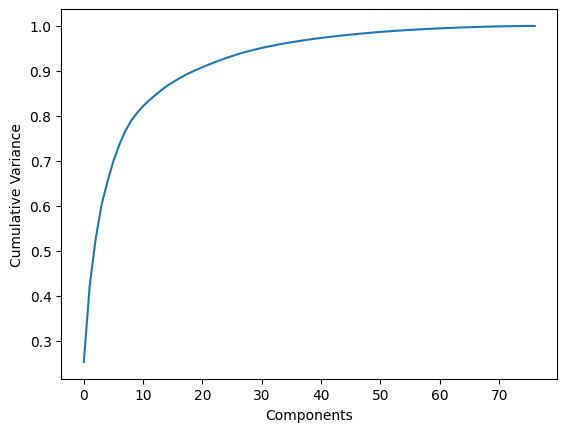

Components for 95% variance: 31


In [61]:


pca = PCA()
pca.fit(X_scaled)

plt.figure()
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel("Components")
plt.ylabel("Cumulative Variance")
plt.show()

n_components = np.argmax(np.cumsum(pca.explained_variance_ratio_) >= 0.95) + 1
print("Components for 95% variance:", n_components)

pca = PCA(n_components=n_components)
X_pca = pca.fit_transform(X_scaled)

2.2 Clusterig on PCA

In [62]:


km_pca = KMeans(n_clusters=k, random_state=0)
labels_pca = km_pca.fit_predict(X_pca)
print("Silhouette PCA+KMeans:", silhouette_score(X_pca, labels_pca))

Silhouette PCA+KMeans: 0.11788899060624773


2.3 Kernel PCA

In [63]:


gamma_grid = [1e-3, 1e-2, 1e-1, 1]

best_kpca_sil = -1
best_kpca_labels = None

for gamma in gamma_grid:
  kpca = KernelPCA(n_components=10, kernel='rbf', gamma=gamma)
  X_kpca = kpca.fit_transform(X_scaled)

  km = KMeans(n_clusters=k, random_state=0)
  labels = km.fit_predict(X_kpca)

  sil = silhouette_score(X_kpca, labels)
  print(f"Gamma={gamma}, Silhouette={sil}")

  if sil > best_kpca_sil:
    best_kpca_sil = sil
    best_kpca_labels = labels

print("Best KPCA Silhouette:", best_kpca_sil)

Gamma=0.001, Silhouette=0.1699200502752777
Gamma=0.01, Silhouette=0.201442391585995
Gamma=0.1, Silhouette=0.5395324430423148
Gamma=1, Silhouette=0.9821250692500666
Best KPCA Silhouette: 0.9821250692500666


Task 3: Pseudo-Label Classification

3.1 Train/Test Split (No Leakage)

In [64]:


X_train, X_test, y_train_true, y_test_true = train_test_split(X, y_true, test_size=0.3, random_state=42, stratify=y_true)

imputer = SimpleImputer(strategy="mean")
scaler = StandardScaler()

X_train = imputer.fit_transform(X_train)
X_train = scaler.fit_transform(X_train)

X_test = imputer.transform(X_test)
X_test = scaler.transform(X_test)

pca = PCA(n_components=n_components)
X_train = pca.fit_transform(X_train)
X_test = pca.transform(X_test)

3.2 Generate Pseudo-Labels

In [65]:


km = KMeans(n_clusters=k, random_state=0)
y_hat_train = km.fit_predict(X_train)

prototypes = []
for i in range(k):
  prototypes.append(X_train[y_hat_train == i].mean(axis=0))
prototypes = np.array(prototypes)

3.3 Minimum Distance Classification

In [69]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_test_encoded = le.fit_transform(y_test_true)

distances = cdist(X_test, prototypes)
y_hat_test = np.argmin(distances, axis=1)

def compute_accuracy(y_pred, y_true):
    y_true = np.array(y_true)  # ensure numpy

    D = max(y_pred.max(), y_true.max()) + 1
    cost_matrix = np.zeros((D, D))

    for i in range(len(y_pred)):
        cost_matrix[y_pred[i], y_true[i]] += 1

    row_ind, col_ind = linear_sum_assignment(cost_matrix.max() - cost_matrix)
    return cost_matrix[row_ind, col_ind].sum() / len(y_pred)

pseudo_acc = compute_accuracy(y_hat_test, y_test_encoded)
print("Pseudo-label test accuracy:", pseudo_acc)

Pseudo-label test accuracy: 0.3549382716049383


Task 4: Bring Back True Labels

4.1 ARI & NMI

In [70]:


ari = adjusted_rand_score(y_true, kmeans_labels[0])
nmi = normalized_mutual_info_score(y_true, kmeans_labels[0])

print("ARI:", ari)
print("NMI:", nmi)

ARI: 0.13973144730994871
NMI: 0.2582508230038573


4.2 Confusion Matrix

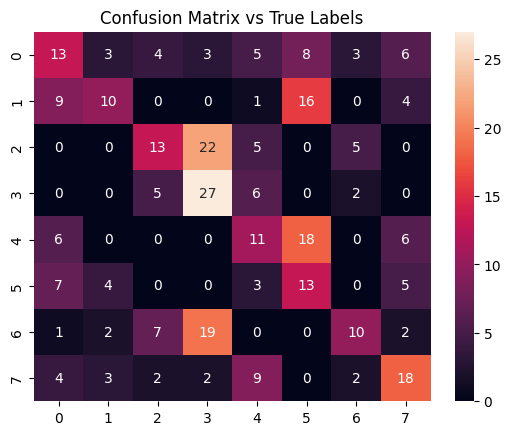

In [71]:




def align_labels(y_pred, y_true):
    D = max(y_pred.max(), y_true.max()) + 1
    cost_matrix = np.zeros((D, D))

    for i in range(len(y_pred)):
        cost_matrix[y_pred[i], y_true[i]] += 1

    row_ind, col_ind = linear_sum_assignment(cost_matrix.max() - cost_matrix)

    mapping = {row: col for row, col in zip(row_ind, col_ind)}

    y_pred_aligned = np.array([mapping[label] for label in y_pred])
    return y_pred_aligned


y_hat_aligned = align_labels(y_hat_test, y_test_encoded)

cm = confusion_matrix(y_test_encoded, y_hat_aligned)

sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix vs True Labels")
plt.show()





4.3 Discussion

Why might PCA/KPCA help or hurt different clustering methods?
For high dimensions Euclidean distances are less informative, points usually seem more equally distant and clusters are harder to separate. PCA helps this by removing low variance directions, improving distance importance and reducing estimation instability. For noise filtering protein measurements usually have experimental variability, batch effects and correlated pathways. PCA isolates strong variance directions that connect to disease vs control patterns and drug response effects.
why might PCA hurt
It may fail when class differences are in low variance directions and strong variance isn't connected to phenotype.

why kernel PCA may help:
It enables nonlinear projections which helps when there are nonlinear protein interactions and if clusters aren't linearly distinct.

why kernel PCA might hurt:
Its very sensitive to gamma where small gamma means almost linear and large gamma means overfitting. This brings problems with artificial cluster distinction and instability among seeds.


Stability across random seeds:

KMeans
-sensitive to initialization and varied results lead to weak clustering structure

GMM
-Sensitive to covariance estimation and more likely to overfit

Kernel methods
-sensitive to large parameters and less sensitive to initialization



Conclusion

Clustering on standardized protein features produced moderate distinction, but overlap between biological conditions was clear. PCA fostered cluster compactness and stability, meaning that a lot of the variance lies in a lower dimensional subspace. Kernel PCA was sensitive to gamma and sometimes improved separation. The pseudo label classifier provided moderate test accuracy, showing that unsupervised structure partly aligns with biological conditions. Although, imperfect ARI/NMI suggests that protein expression clusters do not fully correspond to labeled behavioral phenotypes.

